### Group Project - London Bike Rentals
Team Chardonnay

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [1]:
## Import libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

bikes = pd.read_csv("../Data/london_bikes.csv")
bikes.head()
bikes["date"] = pd.to_datetime(bikes["date"])

# Create useful date variables
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["month_name"] = bikes["date"].dt.month_name()
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season
bikes["season"] = np.select(
    [
        bikes["month"].isin([12, 1, 2]),
        bikes["month"].isin([3, 4, 5]),
        bikes["month"].isin([6, 7, 8]),
        bikes["month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
bikes["season"] = pd.Categorical(
    bikes["season"],
    categories=season_order,
    ordered=True
)

bikes.head()



,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,...,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
0,2010-07-30 00:00:00+00:00,6897,2010,Fri,7,30,6.0,65.0,10147.0,157.0,...,NaN,31.0,17.7,12.3,25.1,False,July,30,Friday,Summer
1,2010-07-31 00:00:00+00:00,5564,2010,Sat,7,30,5.0,70.0,10116.0,184.0,...,NaN,47.0,21.1,17.0,23.9,True,July,31,Saturday,Summer
2,2010-08-01 00:00:00+00:00,4303,2010,Sun,8,30,7.0,63.0,10132.0,89.0,...,NaN,3.0,19.3,14.6,23.4,True,August,1,Sunday,Summer
3,2010-08-02 00:00:00+00:00,6642,2010,Mon,8,31,7.0,59.0,10168.0,134.0,...,NaN,20.0,19.5,15.6,23.6,False,August,2,Monday,Summer
4,2010-08-03 00:00:00+00:00,7966,2010,Tue,8,31,5.0,66.0,10157.0,169.0,...,NaN,39.0,17.9,12.1,20.1,False,August,3,Tuesday,Summer


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

In [2]:
#check for missing values and proportions 
bikes.isna().sum()
bikes.isna().mean() * 100


date             0.000000
bikes_hired      0.000000
year             0.000000
wday             0.000000
month            0.000000
week             0.000000
cloud_cover      0.668829
humidity         1.682205
pressure         0.628293
radiation        0.810701
precipitation    0.628293
snow_depth       6.120794
sunshine         0.628293
mean_temp        0.628293
min_temp         1.256587
max_temp         0.628293
weekend          0.000000
month_name       0.000000
day              0.000000
day_of_week      0.000000
season           0.000000
dtype: float64

The proportion of missing values is relatively low for most variables. However, `snow_depth` has approximately 6% missing values, while `min_temp` and `humidity` have around 1.25% and 1.68%, respectively.

There are two main approaches to handling these missing values: removing rows containing missing observations or imputing the missing values. In this case, replacing missing values with the median may be preferable, as deleting entire rows could result in the unnecessary loss of useful information. The median is a good choice because it is less affected by extreme values and allows us to keep more of the data.


In [3]:
#check data type 
bikes.dtypes

date             datetime64[us, UTC]
bikes_hired                    int64
year                           int32
wday                             str
month                          int32
week                           int64
cloud_cover                  float64
humidity                     float64
pressure                     float64
radiation                    float64
precipitation                float64
snow_depth                   float64
sunshine                     float64
mean_temp                    float64
min_temp                     float64
max_temp                     float64
weekend                         bool
month_name                       str
day                            int32
day_of_week                      str
season                      category
dtype: object

In [4]:
bikes["humidity"] = bikes["humidity"].fillna(bikes["humidity"].median())
bikes["snow_depth"] = bikes["snow_depth"].fillna(bikes["snow_depth"].median())
bikes["min_temp"] = bikes["min_temp"].fillna(bikes["min_temp"].median())

#we can do the same for every column or we can use the code to fill all numeric columns with median values
numeric_cols = bikes.select_dtypes(include="number").columns
bikes[numeric_cols] = bikes[numeric_cols].fillna(bikes[numeric_cols].median())

bikes.isna().mean()*100

date             0.0
bikes_hired      0.0
year             0.0
wday             0.0
month            0.0
week             0.0
cloud_cover      0.0
humidity         0.0
pressure         0.0
radiation        0.0
precipitation    0.0
snow_depth       0.0
sunshine         0.0
mean_temp        0.0
min_temp         0.0
max_temp         0.0
weekend          0.0
month_name       0.0
day              0.0
day_of_week      0.0
season           0.0
dtype: float64

In [5]:
#convert all the columns to the correct data type 
bikes["day_of_week"] = bikes["day_of_week"].astype("category")
bikes["month_name"] = bikes["month_name"].astype("category")

bikes.dtypes

date             datetime64[us, UTC]
bikes_hired                    int64
year                           int32
wday                             str
month                          int32
week                           int64
cloud_cover                  float64
humidity                     float64
pressure                     float64
radiation                    float64
precipitation                float64
snow_depth                   float64
sunshine                     float64
mean_temp                    float64
min_temp                     float64
max_temp                     float64
weekend                         bool
month_name                  category
day                            int32
day_of_week                 category
season                      category
dtype: object

**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



Text(0, 0.5, '')

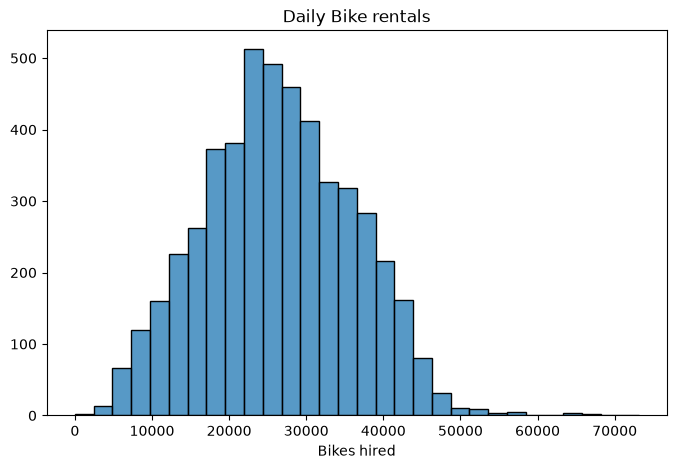

In [7]:
## Distribution of bikes rented
plt.figure(figsize=(8,5))

sns.histplot(data=bikes,
x="bikes_hired",
bins=30
             )
plt.title("Daily Bike rentals")
plt.xlabel("Bikes hired")
plt.ylabel("")

Text(0, 0.5, 'Bikes hired')

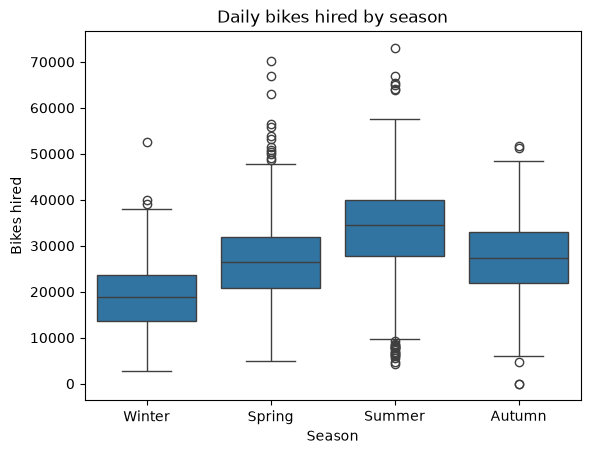

In [8]:
sns.boxplot(
    data=bikes,
    x="season",
    y = "bikes_hired",
)
plt.title("Daily bikes hired by season")
plt.xlabel("Season")
plt.ylabel("Bikes hired")

Text(0, 0.5, 'Bikes hired')

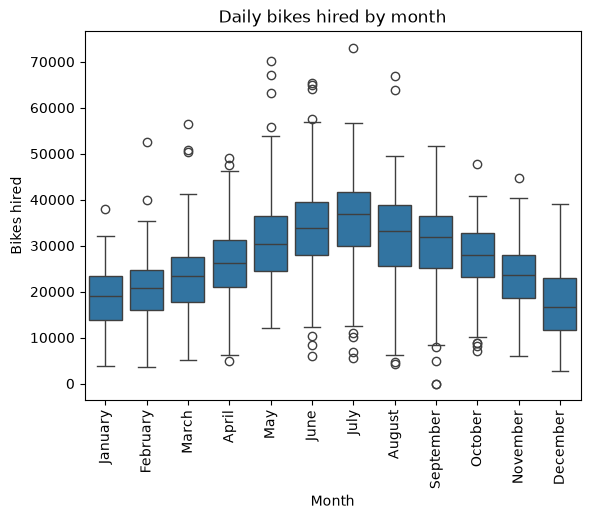

In [5]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

sns.boxplot(
    data=bikes,
    x="month_name",
    y="bikes_hired",
    order=month_order
)

plt.title("Daily bikes hired by month")
plt.xlabel("Month")
plt.xticks(rotation=90)
plt.ylabel("Bikes hired")

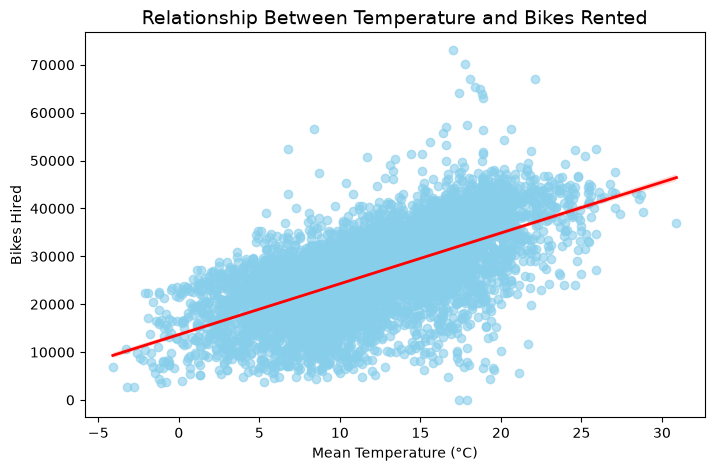

In [ ]:
plt.figure(figsize=(8, 5))

# use regplot to create scatterplot and add a regression line to show its trend
sns.regplot(
    data=bikes,
    x="mean_temp",
    y="bikes_hired",
    color="skyblue",
    line_kws={"color": "red", "linewidth": 2},  
    scatter_kws={"alpha": 0.6},  
)

plt.title("Relationship Between Temperature and Bikes Rented", fontsize=14)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Bikes Hired")

plt.show()

Clearly, as the weather gets warmer, London residents are more likely to rent bikes. From the charts, “Daily bikes hired by season” and “Daily bikes hired by month” we can see that summer and the months from May to August saw the highest number of bike rentals. Furthermore, the scatter plot, “Relationship Between Temperature and Bike Rentals,” shows a positive relationship between temperature and the number of bikes rented, which further supports this observation.

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

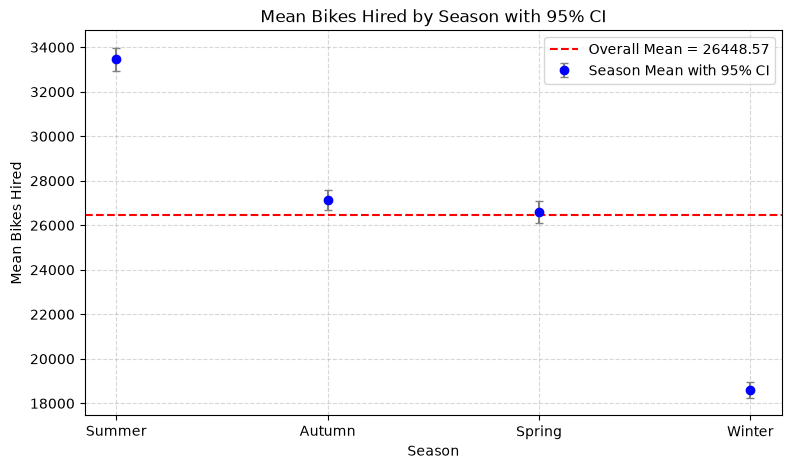

,season,Rental_mean,std,count,t_critical,ser,margin_of_error,CI_lower,CI_upper
2,Summer,33455.454841,9147.748858,1229,1.961898,260.938578,511.934790,32943.520052,33967.389631
3,Autumn,27136.845369,7857.506100,1274,1.961829,220.140533,431.878137,26704.967232,27568.723506
1,Spring,26609.178930,8660.272182,1196,1.961951,250.418236,491.308340,26117.870590,27100.487270
0,Winter,18610.162753,6625.762758,1235,1.961888,188.539522,369.893476,18240.269277,18980.056229


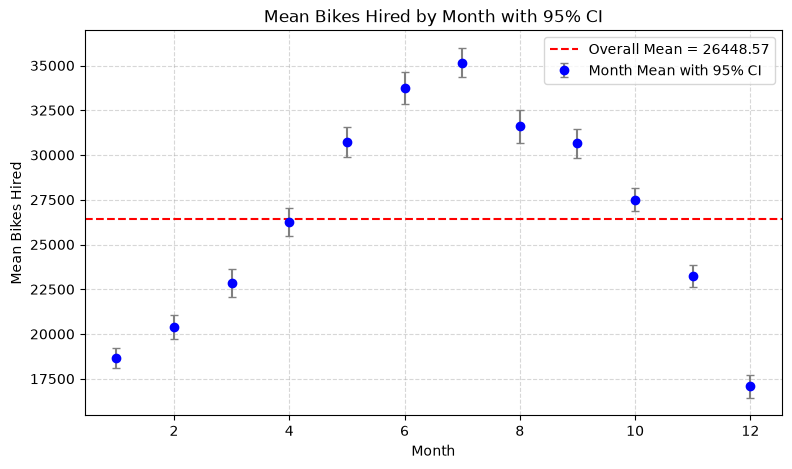

,month,Rental_mean,std,count,t_critical,ser,margin_of_error,CI_lower,CI_upper
6,7,35160.679012,8371.380378,405,1.965853,415.977235,817.750210,34342.928802,35978.429223
5,6,33744.102564,8765.336470,390,1.966081,443.850065,872.645209,32871.457355,34616.747773
7,8,31604.790323,9832.833248,434,1.965458,471.991100,927.678568,30677.111754,32532.468891
4,5,30722.198511,8561.905067,403,1.965883,426.498870,838.446734,29883.751777,31560.645245
8,9,30647.840476,8260.433461,420,1.965642,403.067881,792.287092,29855.553385,31440.127568
9,10,27510.831797,6896.999490,434,1.965458,331.066570,650.697358,26860.134440,28161.529155
3,4,26242.038462,7775.298629,390,1.966081,393.717551,774.080621,25467.957841,27016.119082
10,11,23239.397619,6516.006115,420,1.965642,317.948542,624.972958,22614.424661,23864.370577
2,3,22851.456576,7739.305269,403,1.965883,385.522256,757.891518,22093.565058,23609.348094
1,2,20370.174387,6528.789817,367,1.966467,340.800054,670.171966,19700.002421,21040.346353


In [ ]:
## Create a function to caculate confidence Interval



def plot_group_ci(group_col, data=bikes, value_col='bikes_hired'):

    # prepare table for data's mean std and count
    df_ci = (
        data
        .groupby(group_col)[value_col]
        .agg(
            Rental_mean="mean",
            std="std",
            count="count"
        )
        .reset_index()
    )
    
    # 2. cacluate 95% confidence interval (t-distribution)
    df_ci['t_critical'] = df_ci['count'].apply(lambda n: stats.t.ppf(0.975, df=n-1))
    df_ci['ser'] = df_ci['std'] / np.sqrt(df_ci['count'])
    df_ci['margin_of_error'] = df_ci['t_critical'] * df_ci['ser']
    df_ci['CI_lower'] = df_ci['Rental_mean'] - df_ci['margin_of_error']
    df_ci['CI_upper'] = df_ci['Rental_mean'] + df_ci['margin_of_error']
    
    # ordering the day through mean in descending order
    df_ci = df_ci.sort_values(by='Rental_mean', ascending=False)
    
    # 3. caculate overall mean
    overall = data[value_col].mean()
    
    # 4. draw figure
    plt.figure(figsize=(9, 5))
    
    # create error bar to show range of interval
    plt.errorbar(
        x=df_ci[group_col], 
        y=df_ci['Rental_mean'], 
        yerr=df_ci['margin_of_error'],
        fmt='o', 
        ecolor='gray', 
        capsize=3,
        color='blue',
        label=f'{group_col.capitalize()} Mean with 95% CI'
    )
    
    # draw overall mean on the plot
    plt.axhline(
        overall, 
        color='red', 
        linestyle='--',
        label=f'Overall Mean = {overall:.2f}'
    )
    
    # label the picture
    plt.xlabel(group_col.capitalize())
    plt.ylabel(f'Mean {value_col.replace("_", " ").title()}')
    plt.title(f'Mean {value_col.replace("_", " ").title()} by {group_col.capitalize()} with 95% CI')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()
    display(df_ci)
    



plot_group_ci("season")
plot_group_ci("month")





1. **Seasonal and Monthly Trends in Bike Hires (`bike_hired`):**
   - **Seasonal Pattern (Table 1):** The true population mean of bike hires for each season is estimated to fall within its respective confidence interval. **Summer** clearly exhibits the highest mean rental volume, whereas **winter** records the lowest.
   - **Monthly Pattern (Table 2):** The confidence intervals show that **months 5 through 8** (May to August) achieve the highest average bike hires.

2. **Statistical Significance of Overlapping Intervals:**
   - The overlap in confidence intervals among these months indicates that there is **no statistically significant difference** between their mean bike hire volumes.

**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

In [18]:
model1 = smf.ols(
    'bikes_hired ~ mean_temp + precipitation + humidity + sunshine + cloud_cover',
    data=bikes
).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     1039.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:47:00   Log-Likelihood:                -50507.
No. Observations:                4934   AIC:                         1.010e+05
Df Residuals:                    4928   BIC:                         1.011e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2.274e+04   1342.697     16.940

### Solution Description:

We used linear and regression models with multiple variables in the columns. 
Above is the multiple regression model to determine - How the bikes rented depends on mean_temp, precipitation, humidity, sunshine and cloud cover. 
What does co-efficient tell us from result produced?
- With **mean_temp increase by 1 unit,** predicted bike rentals **increase by 825.9 ~ 826**.[When all other values - precipitation, humidity, sunshine and cloud remain constant. The same apply to all other co-efficients.]
- When **precipitation increase by 1 unit,** there would be **36 less bike rentals**.
- When **humidity increases by 1 unit**, there would be **101 less bike rentals**.
- When **sunshine increase by 1 unit**, predicted bike rental **increase by 51**.
- When **cloud cover increase by 1 unit**, there would be **8.6 ~ 7 less bike rentals**.

The R-squared value says that **51.3% variation in bike rentals** based on - mean_temp, precipitation, humidity, sunshine and cloud cover.

In [19]:
model6 = smf.ols(
    'bikes_hired ~ mean_temp + precipitation + humidity + weekend + C(season) + sunshine + cloud_cover',
    data=bikes
).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     704.7
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:47:16   Log-Likelihood:                -50241.
No. Observations:                4934   AIC:                         1.005e+05
Df Residuals:                    4924   BIC:                         1.006e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            2.509e+04   1

In Addition to the previous regression model, this model we used "Seasons" as additional parameter.
This change shows that there is **56.3% variation** in the bike rentals based on - mean_temp , precipitation, humidity, weekend, C(season), sunshine, cloud_cover.

What does co-efficient tell us from result produced?
- With Seasons being the categorical data :
   1. Spring, Summer and Autumn are measured in comparision to Winter. 
   2. When **compared to winter** - **Summer** is predicted to have **~2725 more** bike rentals, **Spring** is predicted to have **~1376 more** bike rentals and **Autumn** is predicted to have **~3097 more** bike rentals than winter.
   3. Weekend is likely predicted to have **~4312 less** bike rentals than on weekdays.

- With **mean_temp increase by 1 unit,** predicted bike rentals **increase by 825.9 ~ 826**.[When all other values - precipitation, humidity, sunshine and cloud remain constant. The same apply to all other co-efficients.]
- When **precipitation increase by 1 unit,** there would be **36 less bike rentals**.
- When **humidity increases by 1 unit**, there would be **101 less bike rentals**.
- When **sunshine increase by 1 unit**, predicted bike rental **increase by 51**.
- When **cloud cover increase by 1 unit**, there would be **8.6 ~ 7 less bike rentals**.


In order to improve the result, we furthur do some experiment, we selected more variables to the modals and evaluated whether adding them provided additional explanatory power. We also considered multicollinearity more seriously by using VIF to improve modal stability and compared adjusted R² and test-set performance to avoid adding unnecessary variables.


**The following is the step of our new experiment**:
1. Remove repetitive information
    1. wday = day_of_week -> eliminate day_of_week
    2. month = month_name -> eliminate month_name
2. we need to avoid multicollinearity problem, we start with intuitive multicollinearity problem:**
    1. mean_temp = (min+max)/2 -> eliminate mean
    4. weekend_True = wday_Sat + wday_Sun -> eliminate weekend_True
    5. season_Spring = month_3 + month_4 + month_5
    season_Summer = month_6 + month_7 + month_8
    season_Autumn = month_9 + month_10 + month_11 -> eliminate season**
3. Standardize the numerical value
    Because our numerical predictors have different scales, we standardized them so that the coefficients can be compared on a common scale.
4.Check for multicollinearity using VIF,calculate VIF for the predictors.
    identify variables with potentially high multicollinearity and consider removing them.
4. Build and evaluate the model
    Compare R², adjusted R², and test-set performance to evaluate whether the new feature set improves the model.

The following is the result

In [9]:
y = bikes['bikes_hired']


# 1. categorical 
cat_cols = ['wday', 'month',"weekend","season","week"]
cat_cols = [col for col in cat_cols if col in test.columns]
num_cols = ["year", "min_temp","max_temp","mean_temp","humidity", "wind_speed","sunshine","cloud_cover","rainfall","pressure","precipitation","snow_depth","radiation","day"]
num_cols = [col for col in num_cols if col in test.columns]

print("selected variables:", test.columns.tolist())



# standardize data
scaler = StandardScaler()

#  transform numearical value to standardize，Dummy 變數維持 0.0 / 1.0 不變
test[num_cols] = scaler.fit_transform(test[num_cols])

# 2. change data to Dummy
test = pd.get_dummies(test, columns=cat_cols, drop_first=True, dtype=float)

# 3. fill nan
test = test.dropna()
test = sm.add_constant(test)

# # 4. deal with nan
test = test.replace([np.inf, -np.inf], np.nan)
mask = test.notna().all(axis=1) & y.notna()
test = test[mask]
y = y[mask]

test = sm.add_constant(test)

model = sm.OLS(y, test).fit()


print(model.summary())

selected variables: ['year', 'wday', 'month', 'cloud_cover', 'humidity', 'pressure', 'precipitation', 'snow_depth', 'sunshine', 'day', 'mean_temp']
                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     336.1
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:51:36   Log-Likelihood:                -49760.
No. Observations:                4934   AIC:                         9.957e+04
Df Residuals:                    4907   BIC:                         9.975e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|     

In addition to the previous model, this model uses **month (month_2~month_12)** and **weekday (wday_Mon, etc.)** as additional categorical parameters, replacing the previous Season variable.

This model shows that **64.0%** of the variation in bikes_hired can be explained by year, cloud_cover, humidity, pressure, precipitation, snow_depth, sunshine, day, mean_temp, weekday, and month (R-squared = 0.640, Adjusted R-squared = 0.638).

## Categorical Variables (as dummy variables)

**Weekday (baseline = Friday, since wday_Fri does not appear in the table)**
1. Compared to Friday, Monday is predicted to have **~989 fewer** rentals.
2. Compared to Friday, Saturday is predicted to have **~2747 fewer** rentals.
3. Compared to Friday, Sunday is predicted to have **~4825 fewer** rentals — the largest decrease among all categories.
4. Compared to Friday, Tuesday is predicted to have **~1108 more** rentals.
5. Compared to Friday, Wednesday is predicted to have **~1331 more** rentals.
6. Compared to Friday, Thursday is predicted to have **~1145 more** rentals.

**Month (baseline = January, since month_1 does not appear in the table)**
1. Compared to January, February is predicted to have ~683 more rentals, but p = 0.147, **not statistically significant (interpretation not recommended)**.
2. Compared to January, March is predicted to have **~968 more** rentals.
3. Compared to January, April is predicted to have **~1263 more** rentals.
4. Compared to January, May is predicted to have **~3606 more** rentals.
5. Compared to January, June is predicted to have **~4734 more** rentals.
6. Compared to January, July is predicted to have **~4796 more** rentals — the largest increase among all months.
7. Compared to January, August is predicted to have **~2461 more** rentals.
8. Compared to January, September is predicted to have **~3335 more** rentals.
9. Compared to January, October is predicted to have **~4236 more** rentals.
10. Compared to January, November is predicted to have **~3609 more** rentals.
11. Compared to January, December is predicted to have **~1177 fewer** rentals — the only month with a decrease.

## Continuous Variables

> These variables have been standardized, so "1 unit" below refers to "1 standard deviation," not the original raw units (e.g., °C or mm).

- With mean_temp increasing by 1 standard deviation, predicted rentals are estimated to **increase by ~3563** (p = 0.000, holding all other variables constant).
- With year increasing by 1 standard deviation, predicted rentals are estimated to **increase by ~2178** (p = 0.000).
- With pressure increasing by 1 standard deviation, predicted rentals are estimated to **increase by ~960** (p = 0.000).
- With sunshine increasing by 1 standard deviation, predicted rentals are estimated to **increase by ~1409** (p = 0.000).
- With cloud_cover increasing by 1 standard deviation, predicted rentals are estimated to **decrease by ~408** (p = 0.002).
- With humidity increasing by 1 standard deviation, predicted rentals are estimated to **decrease by ~1021** (p = 0.000).
- With precipitation increasing by 1 standard deviation, predicted rentals are estimated to **decrease by ~1181** (p = 0.000).
- With snow_depth increasing by 1 standard deviation, predicted rentals decrease by ~68, but p = 0.422, **not statistically significant (interpretation not recommended)**.
- With day increasing by 1 standard deviation, predicted rentals decrease by ~152, p = 0.066, **not significant at the 5% level (only marginally significant at the 10% level)**.

In [6]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


bikes.head(5)
# remove reptitive columns wday = day_of_week,month=month_name,，and remove y
X = bikes.drop(columns=["date","day_of_week","month_name","bikes_hired"]) 

#remove pontential columns with linear colinarity
X = X.drop(columns=["mean_temp","weekend","season"])



cat_cols = ['wday', 'month',"weekend","season","week"]
cat_cols = [col for col in cat_cols if col in X.columns]
num_cols = ["year", "min_temp","max_temp","mean_temp","humidity", "wind_speed","sunshine","cloud_cover","rainfall","pressure","precipitation","snow_depth","radiation","day"]
# 確保只篩選存在於 X 中的欄位
num_cols = [col for col in num_cols if col in X.columns]

print("selected variables:", X.columns.tolist())

X_V_test = X.copy()


scaler = StandardScaler()


X_V_test[num_cols] = scaler.fit_transform(X_V_test[num_cols])


X_V_test = pd.get_dummies(X_V_test, columns=cat_cols, drop_first=True, dtype=float)


X_V_test = X_V_test.dropna()
X_V_test = sm.add_constant(X_V_test)





assert X_V_test.dtypes.map(lambda t: t.kind in "fi").all(), X_V_test.dtypes[X_V_test.dtypes.map(lambda t: t.kind not in "fi")]

vif = pd.DataFrame({
    "feature": X_V_test.columns,
    "VIF": [variance_inflation_factor(X_V_test.values, i) for i in range(X_V_test.shape[1])],
})
print(vif[vif["feature"] != "const"].sort_values("VIF", ascending=False))

selected variables: ['year', 'wday', 'month', 'week', 'cloud_cover', 'humidity', 'pressure', 'radiation', 'precipitation', 'snow_depth', 'sunshine', 'min_temp', 'max_temp', 'day']
          feature        VIF
24        month_8  54.195152
23        month_7  52.802344
22        month_6  49.873700
25        month_9  48.493012
21        month_5  47.421446
..            ...        ...
80        week_53   1.316139
4        pressure   1.305415
6   precipitation   1.242834
7      snow_depth   1.064782
1            year   1.053711

[80 rows x 2 columns]


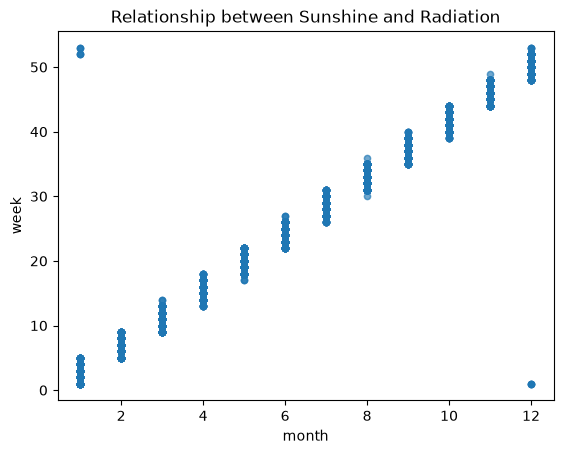

          month      week
month  1.000000  0.972215
week   0.972215  1.000000


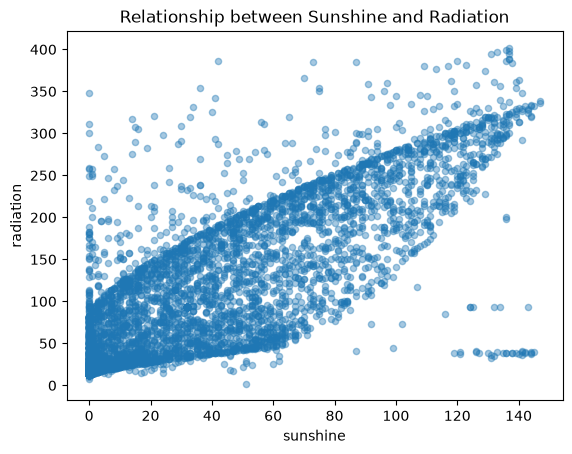

           sunshine  radiation
sunshine   1.000000   0.777869
radiation  0.777869   1.000000


In [12]:
#From the above we can see the VIF for month is extremely high also for the sunshine, meaning that it has high collinarity with others. So we do a further test of them

bikes.plot.scatter(x="month", y="week", alpha=0.4)
plt.title("Relationship between Sunshine and Radiation")
plt.show()
print(bikes[["month", "week"]].corr())

bikes.plot.scatter(x="sunshine", y="radiation", alpha=0.4)
plt.title("Relationship between Sunshine and Radiation")
plt.show()
print(bikes[["sunshine", "radiation"]].corr())

**Frome the above observation we could remove radiation and week, cause they have high correlation**

In [8]:

print(X.columns.tolist())
print(X.head(5))

test=X.copy()
# test = test.drop(columns=[ "radiation","week"])
test = test.drop(columns=[ "radiation","week",'min_temp','max_temp'])
test["mean_temp"]=bikes["mean_temp"]

print(test.columns.tolist())
print(test.head(5))


['year', 'wday', 'month', 'week', 'cloud_cover', 'humidity', 'pressure', 'radiation', 'precipitation', 'snow_depth', 'sunshine', 'min_temp', 'max_temp', 'day']
   year wday  month  week  cloud_cover  humidity  pressure  radiation  \
0  2010  Fri      7    30          6.0      65.0   10147.0      157.0   
1  2010  Sat      7    30          5.0      70.0   10116.0      184.0   
2  2010  Sun      8    30          7.0      63.0   10132.0       89.0   
3  2010  Mon      8    31          7.0      59.0   10168.0      134.0   
4  2010  Tue      8    31          5.0      66.0   10157.0      169.0   

   precipitation  snow_depth  sunshine  min_temp  max_temp  day  
0           22.0         0.0      31.0      12.3      25.1   30  
1            0.0         0.0      47.0      17.0      23.9   31  
2            0.0         0.0       3.0      14.6      23.4    1  
3            0.0         0.0      20.0      15.6      23.6    2  
4            0.0         0.0      39.0      12.1      20.1    3  
['yea

## Deliverables
A knitted HTML, one person per group to submit